# Observability matrices for orphan GRB afterglows

Be patient for this notebook, it is not well optimised and the computation of the matrices can take some time... :)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import afterglowpy as grb
import math 
from astropy.cosmology import Planck18 as cosmo

In [2]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [3]:
from matplotlib.ticker import FormatStrFormatter

## Useful functions

In [4]:
def obs_duration(t, mag):
    """Function that compute the number of days for which the afterglow is observable (mag < 24.5)
    """
    
    obs_t = t[np.where(mag < 24.5)[0]]
    
    if obs_t.size == 0:
        return 0
    else:
        return (max(obs_t) - min(obs_t))*grb.sec2day

In [24]:
def compute_matrix(config, thetaCore, thetaWing, thetaObs):
    """Function that compute the observability duration for each combination (thetaCore, thetaWing, thetaObs)
    """
    
    obs_time = np.zeros((len(thetaObs), len(thetaWing), len(thetaCore)))
    
    # loop through thetaCore, thetaWing, and thetaObs
    for c, tc in enumerate(thetaCore):

        config_copy = config.copy()
        config_copy['thetaCore'] = tc 
        
        for w, tw in enumerate(thetaWing):
            if tc < tw:

                config_copy['thetaWing'] = tw
                
                for o, to in enumerate(thetaObs):
                    if tc + to < np.pi / 2:
                        config_copy['thetaObs'] = tc + to

                        try:
                            # calculate flux and magnitude
                            Fnu = grb.fluxDensity(t, nu, **config_copy)
                            mag = -2.5 * np.log10(Fnu * 1.0e-26) - 48.6
                            
                            if min(mag) < 24.5:
                                obs_time[o, w, c] = obs_duration(t, mag)
                        except:
                            continue
                        
    return obs_time

In [6]:
def plot_matrix(obs_time, thetaCore, thetaWing, thetaObs):
    """Function that plot the observability duration in a matrix
    """

    thetaCore_deg = np.degrees(thetaCore)
    thetaWing_deg = np.degrees(thetaWing)
    thetaObs_deg = np.degrees(thetaObs)
    
    #colors = ['#296073', '#5f93a7', '#19a594', '#f49432', '#32517e', '#00283f']
    colors = ['#03045e', '#023e8a', '#0077b6', '#0096c7', '#00b4d8', '#48cae4', '#90e0ef']
    
    plt.rcParams.update({'font.size': 25})
    fig = plt.figure(figsize=(12., 12.))
    ax = fig.add_subplot(111)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    thetaCore_mesh, thetaWing_mesh = np.meshgrid(thetaCore_deg, thetaWing_deg)
    
    thetaCore_flat = thetaCore_mesh.flatten()
    thetaWing_flat = thetaWing_mesh.flatten()
    
    scatter_points = []
    text_labels = []

    for i, to in enumerate(thetaObs_deg):
        for j, tw in enumerate(thetaWing_deg):
            for k, tc in enumerate(thetaCore_deg):
                if tc + to < 90:  # thetaWing + thetaObs < pi/2 (degrees)
                    obs = obs_time[i, j, k]
                    if obs >= 0.1:  # we only care about observable durations
                        scatter_points.append((tc, tw, colors[i], obs))
                        text_labels.append((tc, tw, obs, colors[i], i))
    

    for tc, tw, color, _ in scatter_points:
        ax.scatter(tc, tw, color=color, alpha=1, s=50)
    
    for tc, tw, obs, color, i in text_labels:
        ax.text(tc - 0.9, tw - (i * 0.9) + 0.6, f'{obs:.1f}', color=color, fontsize=20)
    
    ax.set_xlabel(r'$\theta_c$ (deg)', fontsize=30)
    ax.set_ylabel(r'$\theta_w$ (deg)', fontsize=30)
    ax.set_xlim(1., 12.)
    ax.set_ylim(-0., 31.)
    
    plt.fill_between([-1., 18.], [-1., 18.], -10., color='k', alpha=0.1)

    theta_leg = [mpatches.Patch(color=color, label=r'$\theta_{obs}$ = $\theta_c$ + %.2f°' % to) for to, color in zip(thetaObs_deg, colors)]
    ax.legend(handles=theta_leg, loc='lower right', fontsize=23)

    ax.set_xticks(np.degrees(thetaCore))
    ax.set_yticks(np.degrees(thetaWing))

    ax.grid()
    plt.savefig('../figures/matrix_52_01.pdf', format="pdf", bbox_inches="tight", transparent=True)
    plt.show()

## Parameters

For a short GRB, the chosen parameters are :
- $z_{max} = 0.1 \sim 475$ Mpc : the redshift is limited with the limit of detection of LIGO (O4/O5 $\sim 350$ Mpc),
- $n$ between $1$ and $0.001$ cm$^{-3}$ (we took $0.05$ cm$^{-3}$),
- $E$ between 10$^{50}$ erg and 10$^{53}$ erg.

We limit the angles : 
- $\theta_w > \theta_c$, 
- $\theta_{w,max} = 28.65°$,
- $\theta_{c,max} = 14.32°$,

In [7]:
t = np.geomspace(1.0e3, 1.0e10, 300)
nu = 5.0e14 

thetaCore = [0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2]
thetaWing = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
thetaObs = [0.15, 0.2, 0.3, 0.4, 0.5]

n = 0.05

In [8]:
Z = {'jetType':     grb.jet.PowerLaw,   # Jet Type
     'specType':    0,                  # Emission Spectrum
     'b':           4,                  # Power Law index
     'thetaObs':    0.25,               # Viewing angle
     'E0':          1.0e52,             # Isotropic-equivalent energy in erg
     'thetaWing':   0.2,                # Truncation angle
     'thetaCore':   0.1,                # Half-opening angle in radians
     'n0':          0.1,                # Circumburst density in cm^{-3}
     'p':           2.2,                # Electron energy distribution index
     'epsilon_e':   0.1,                # epsilon_e
     'epsilon_B':   0.01,               # epsilon_B
     'xi_N':        1.0,                # Fraction of electrons accelerated
     'd_L':         1.0e28,             # Luminosity distance in cm
     'z':           0.01}               # Redshift

## 1. $z = 0.01$ 

In [9]:
Z['z'] = 0.01
Z['d_L'] = cosmo.luminosity_distance(Z['z']).value*3.08e24

### 1.1 $E = 10^{50}$ erg

In [10]:
Z['E0'] = 1.*10**50

In [11]:
obs_time_001_50 = compute_matrix(Z, thetaCore, thetaWing, thetaObs)

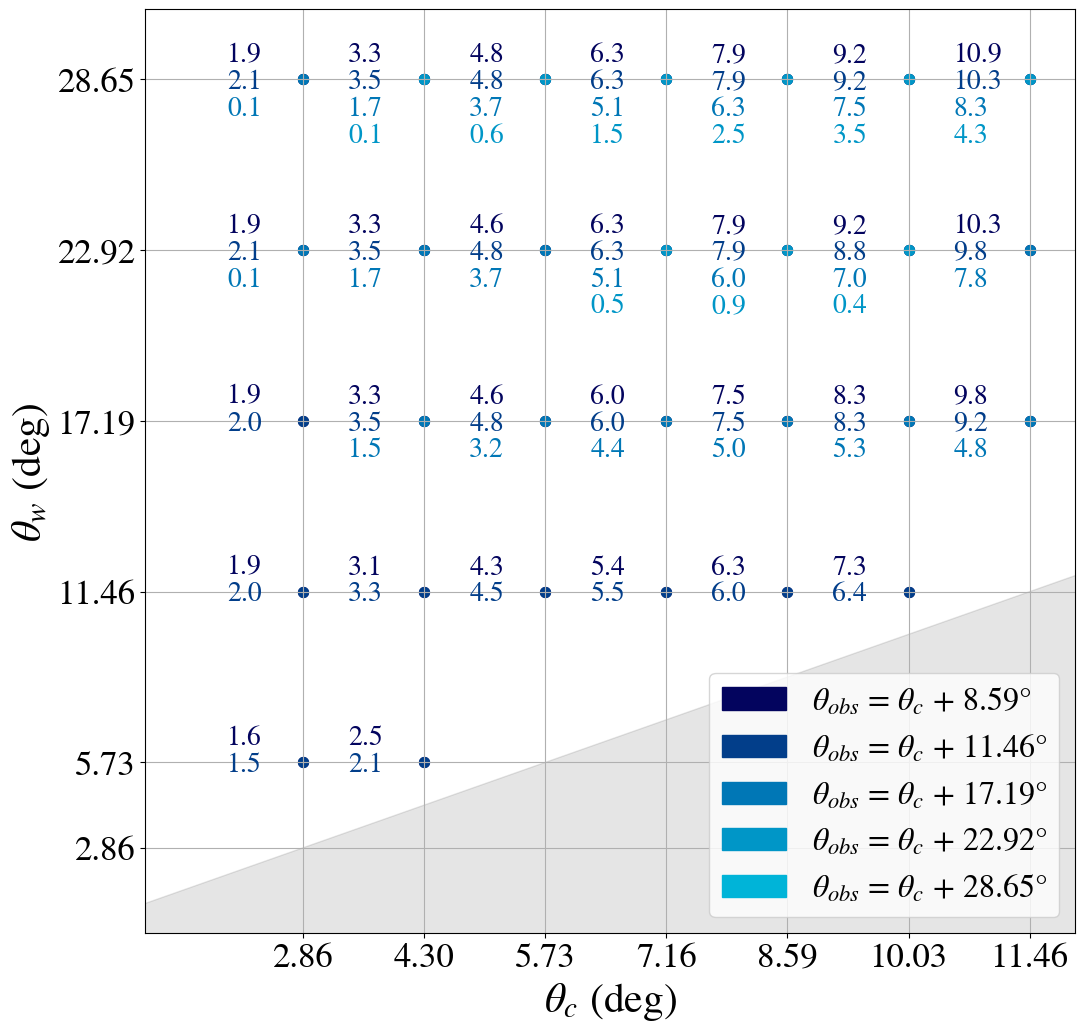

In [12]:
matrix_001_50 = plot_matrix(obs_time_001_50, thetaCore, thetaWing, thetaObs)

### 1.2 $E = 10^{51}$ erg

In [13]:
Z['E0'] = 1.*10**51

In [14]:
obs_time_001_51 = compute_matrix(Z, thetaCore, thetaWing, thetaObs)

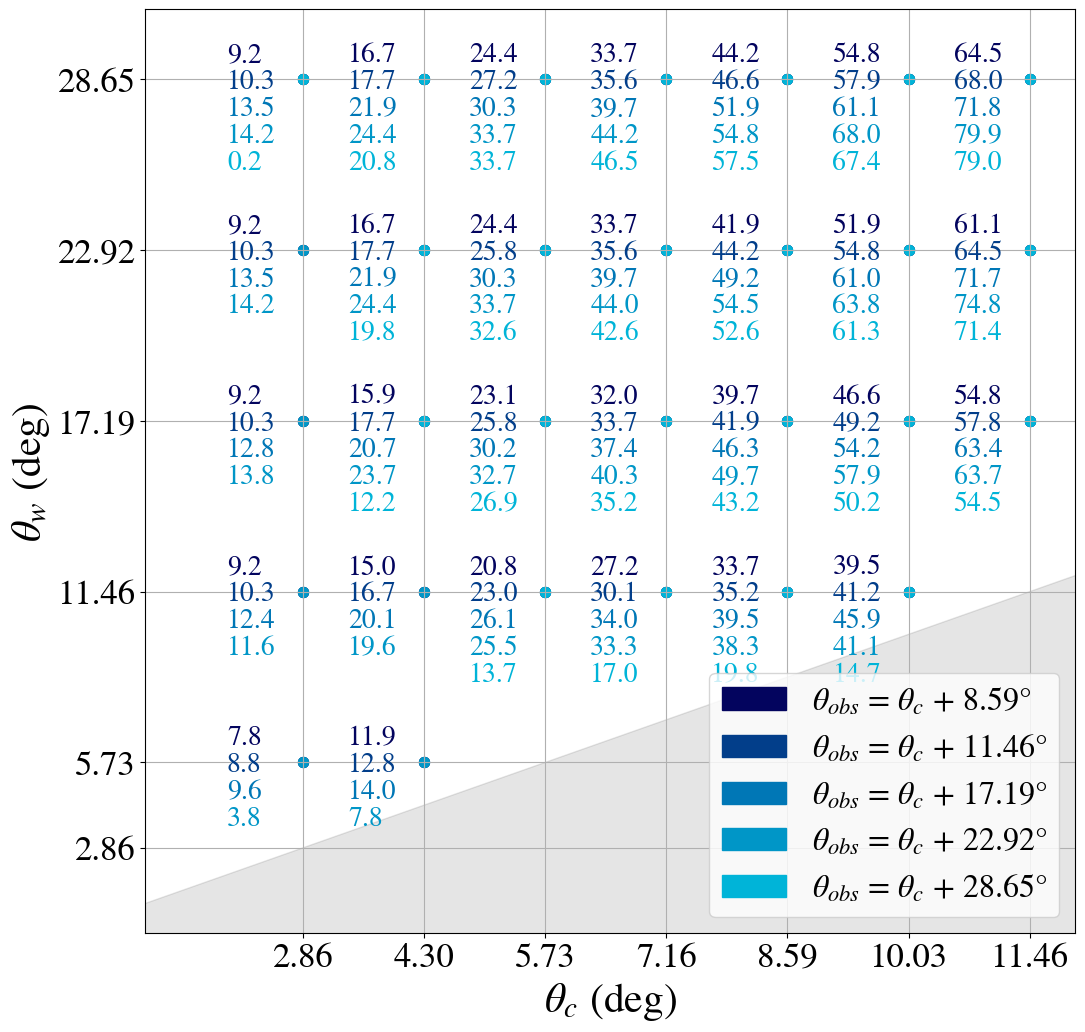

In [15]:
matrix_001_51 = plot_matrix(obs_time_001_51, thetaCore, thetaWing, thetaObs)

### 1.3 $E = 10^{52}$ erg

In [16]:
Z['E0'] = 1.*10**52

In [17]:
obs_time_001_52 = compute_matrix(Z, thetaCore, thetaWing, thetaObs)

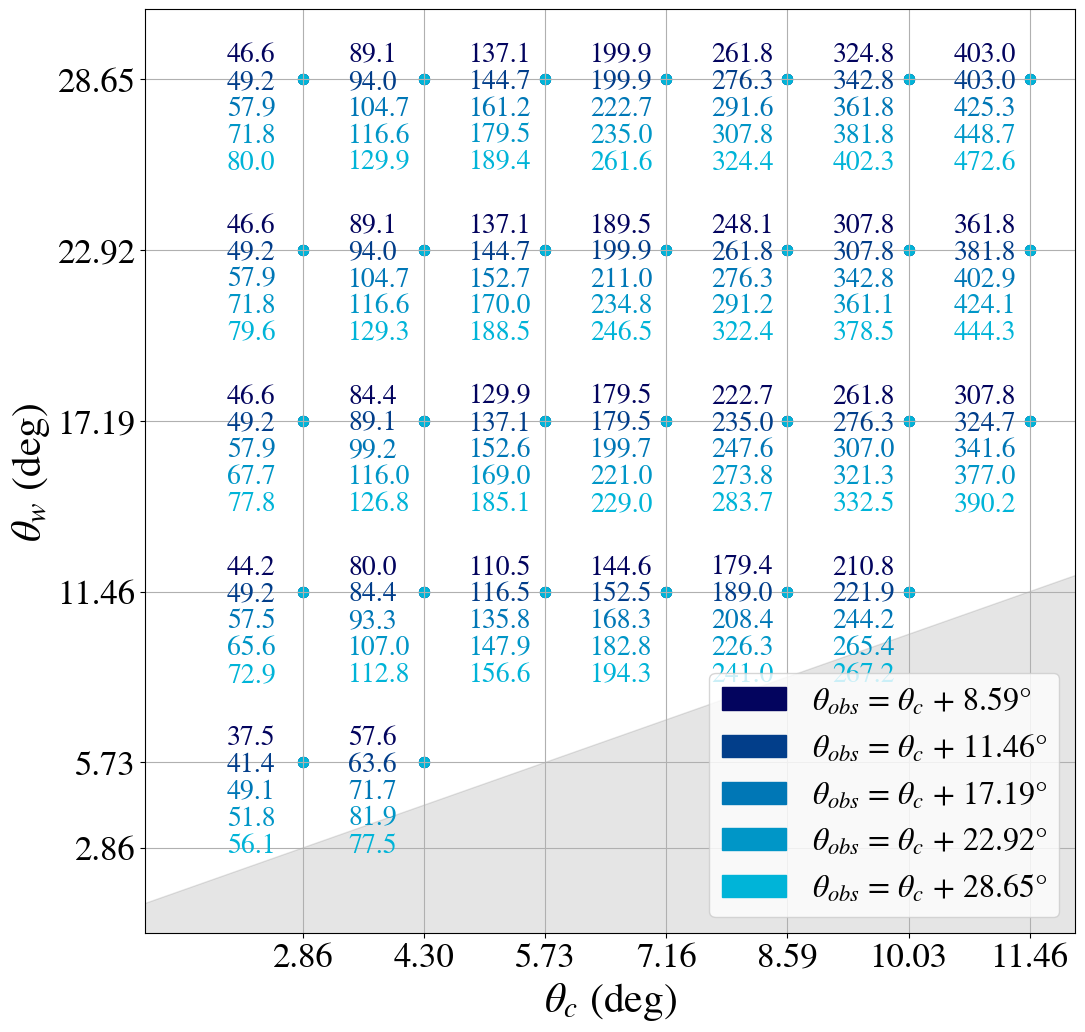

In [18]:
matrix_001_52 = plot_matrix(obs_time_001_52, thetaCore, thetaWing, thetaObs)

#### 1.3 $E = 10^{53}$ erg

In [19]:
Z['E0'] = 1.*10**53

In [25]:
obs_time_001_53 = compute_matrix(Z, thetaCore, thetaWing, thetaObs)

bad em:-nan te=-nan mu=-nan
error in afterglowpy
Oh no there's an error
Oh no there's an error
Oh no there's an error
Oh no there's an error


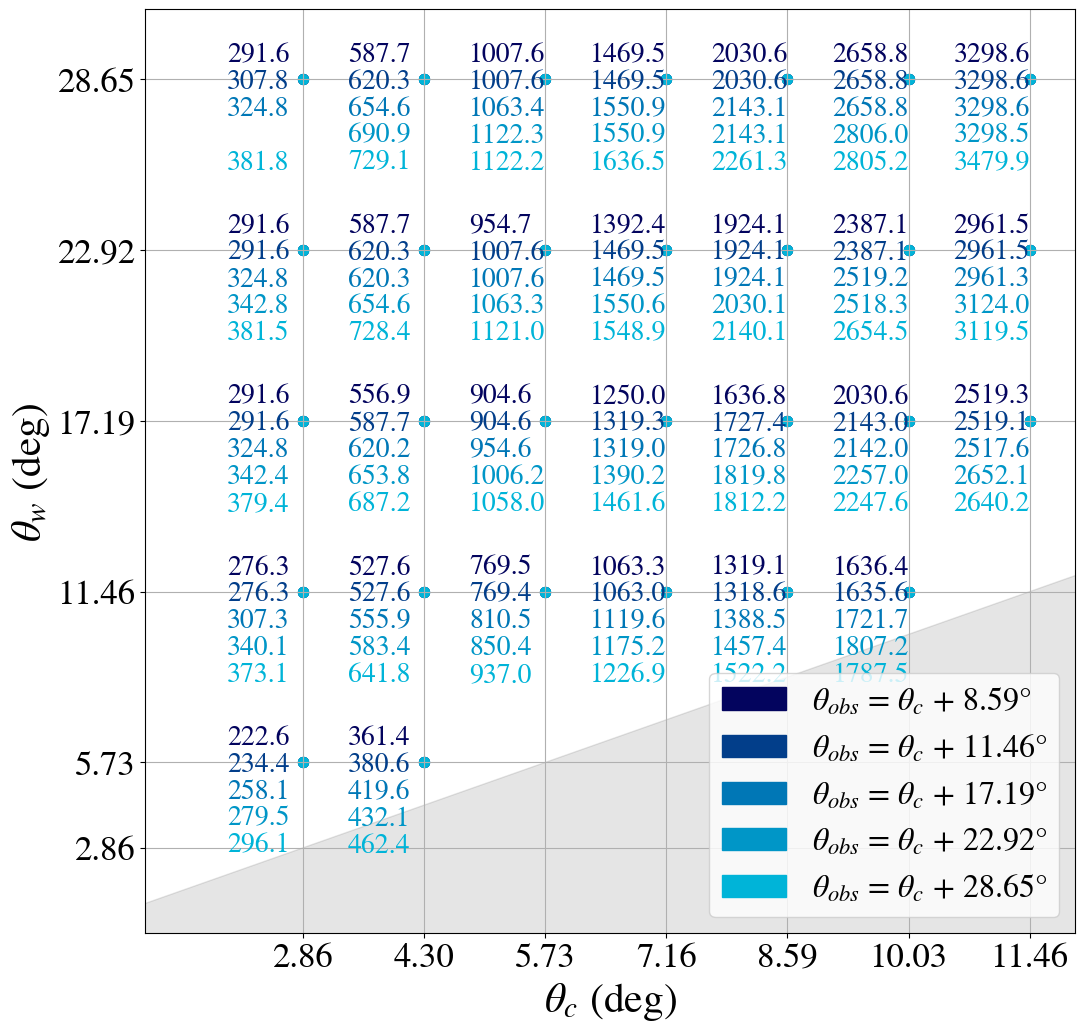

In [26]:
matrix_001_53 = plot_matrix(obs_time_001_53, thetaCore, thetaWing, thetaObs)

## 2. $z = 0.1$

In [27]:
Z['z'] = 0.1
Z['d_L'] = cosmo.luminosity_distance(Z['z']).value*3.08e24
Z['n0'] = 0.1

#### 2.1 $E = 10^{50}$ erg

In [28]:
Z['E0'] = 1e50

In [29]:
obs_time_01_50 = compute_matrix(Z, thetaCore, thetaWing, thetaObs)

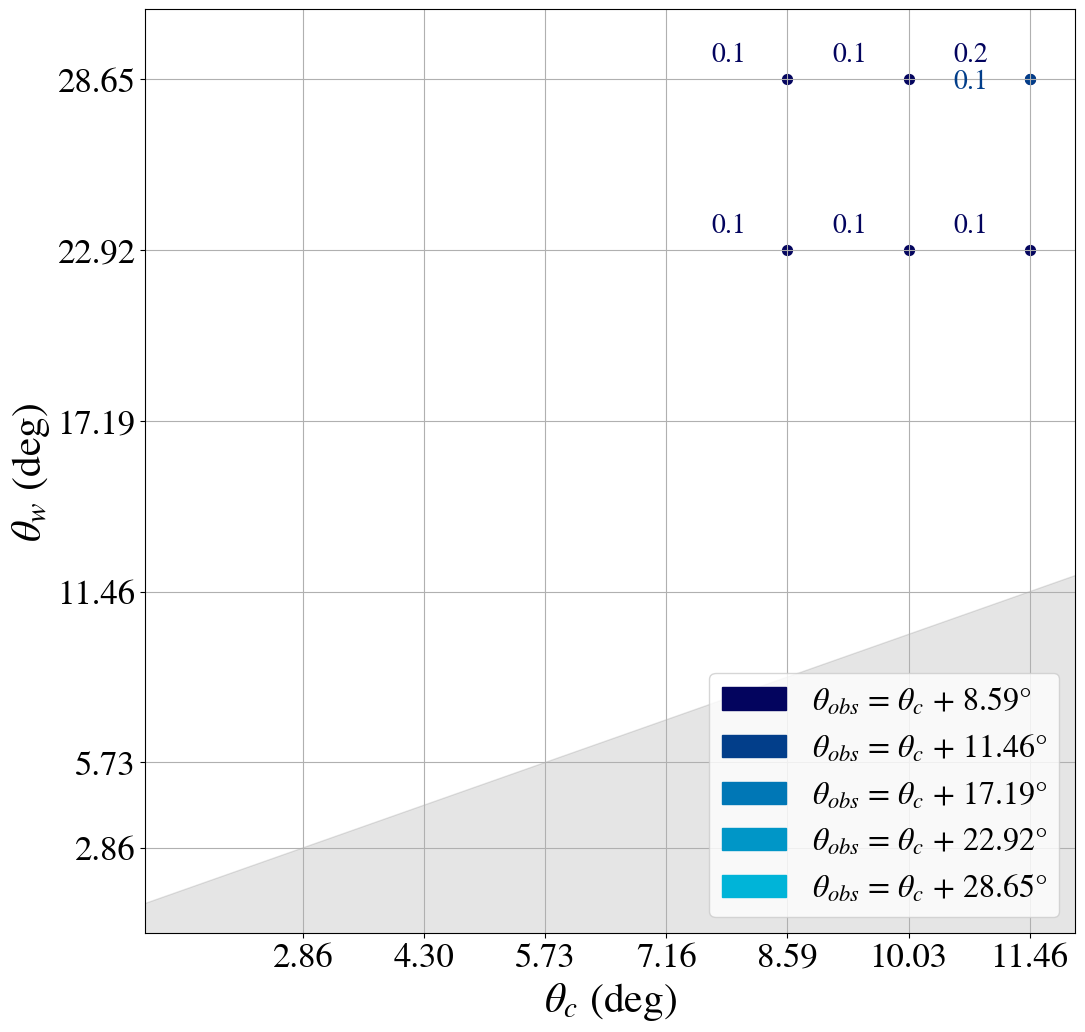

In [30]:
matrix_01_50 = plot_matrix(obs_time_01_50, thetaCore, thetaWing, thetaObs)

#### 2.2 $E = 10^{51}$ erg

In [31]:
Z['E0'] = 1.*10**51

In [32]:
obs_time_01_51 = compute_matrix(Z, thetaCore, thetaWing, thetaObs)

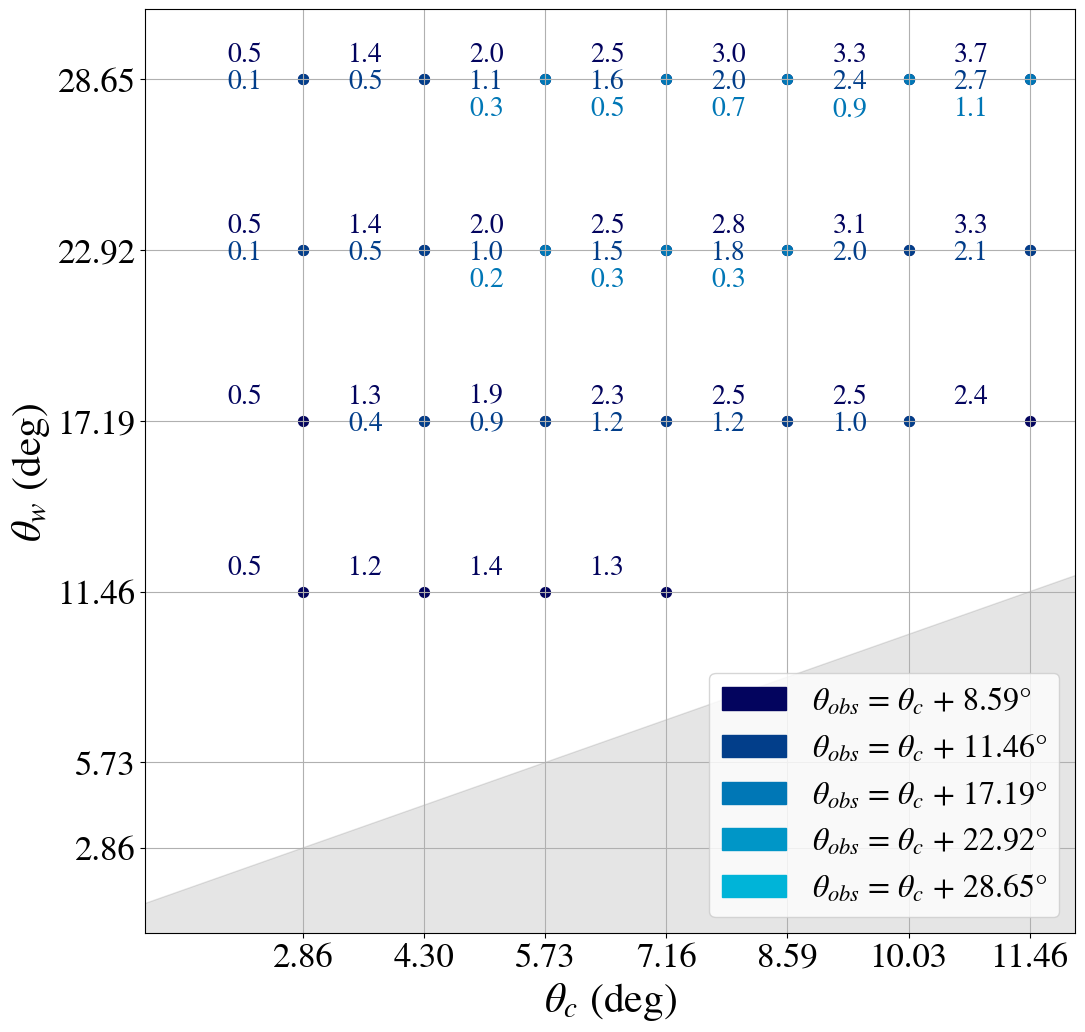

In [33]:
matrix_01_51 = plot_matrix(obs_time_01_51, thetaCore, thetaWing, thetaObs)

#### 2.3 $E = 10^{52}$ erg

In [34]:
Z['E0'] = 1.*10**52
Z['n0'] = 0.1

In [35]:
obs_time_01_52 = compute_matrix(Z, thetaCore, thetaWing, thetaObs)

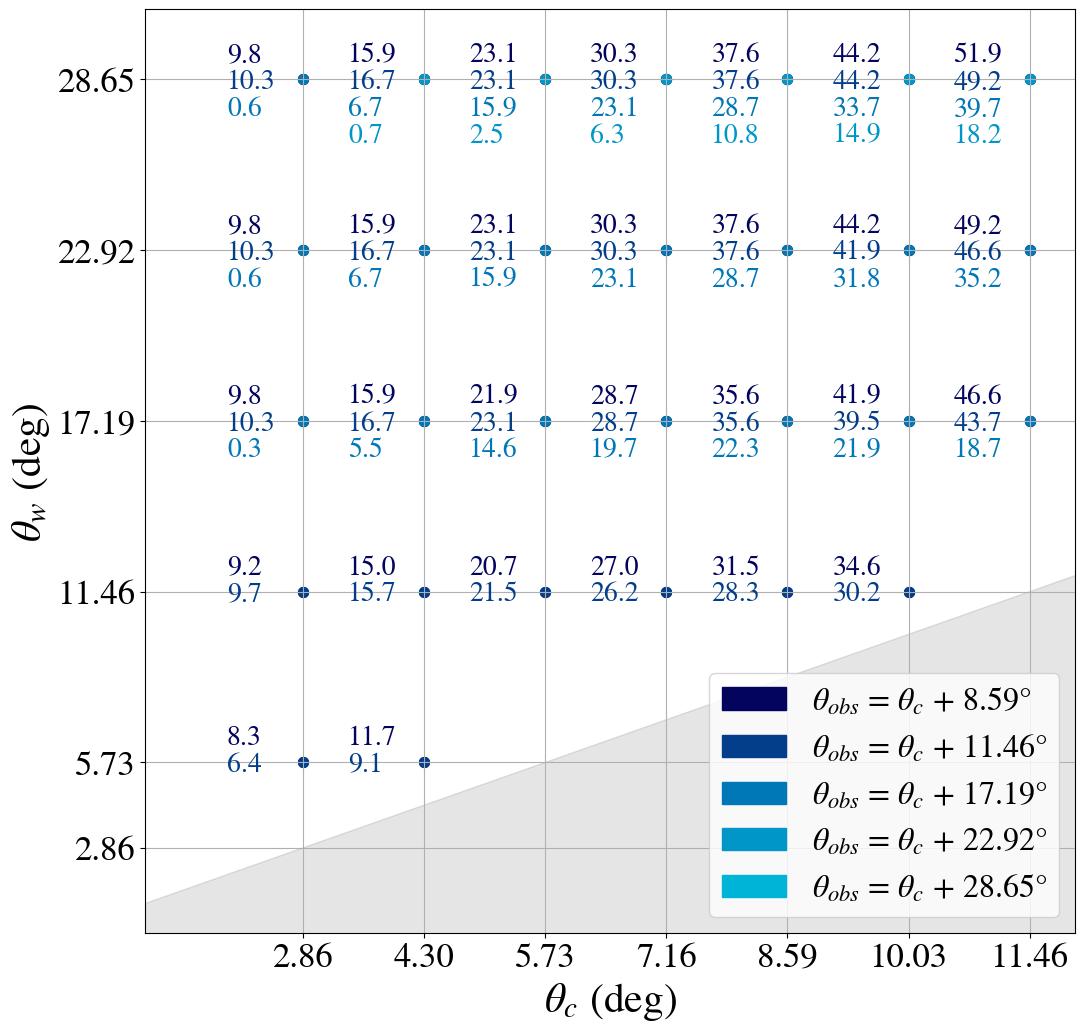

In [36]:
matrix_01_52 = plot_matrix(obs_time_01_52, thetaCore, thetaWing, thetaObs)

#### 2.3 $E = 10^{53}$ erg

In [37]:
Z['E0'] = 1.*10**53
Z['n0'] = 0.01

In [39]:
obs_time_01_53 = compute_matrix(Z, thetaCore, thetaWing, thetaObs)

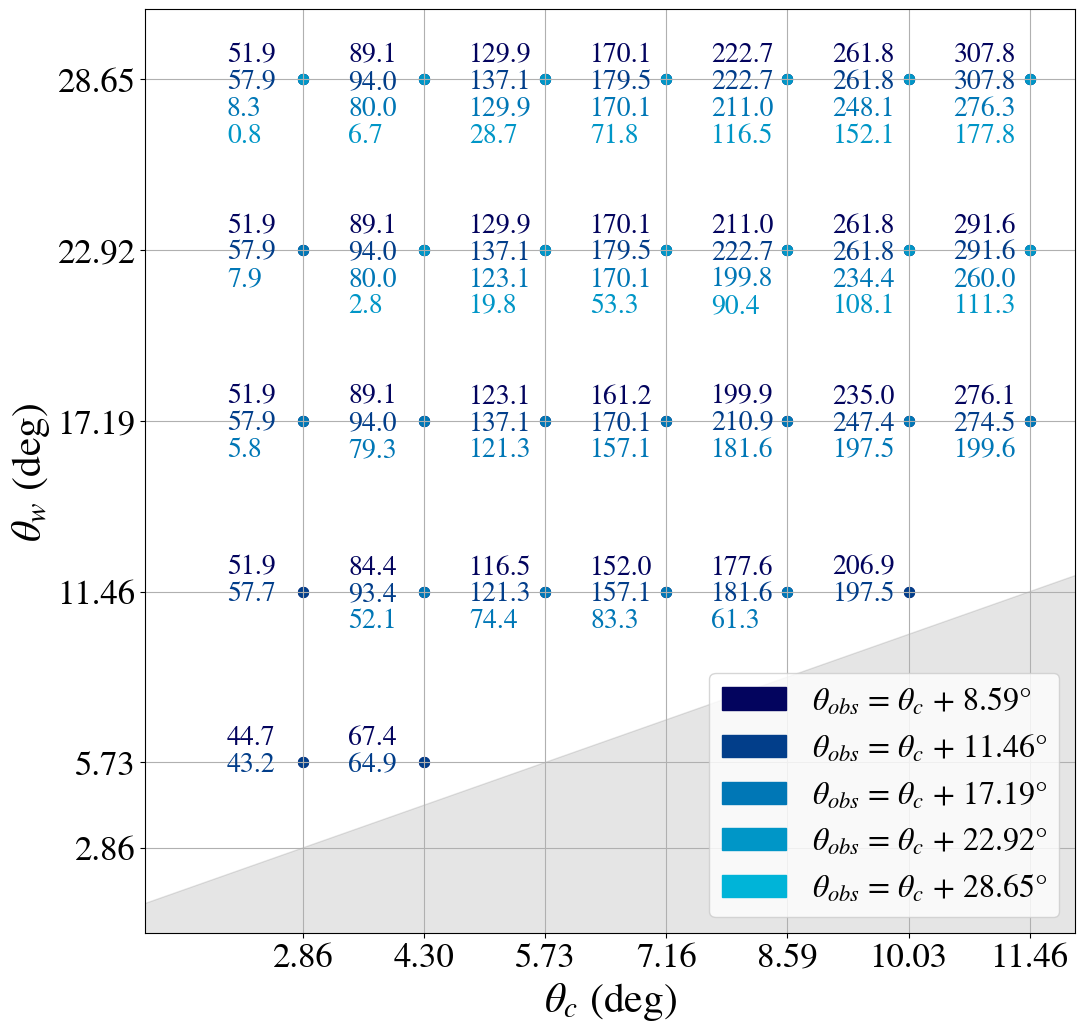

In [40]:
matrix_01_53 = plot_matrix(obs_time_01_53, thetaCore, thetaWing, thetaObs)